# Exploratory Data Analysis (EDA)
## Original Training Dataset: train_nor_811.xlsx

This notebook performs basic exploratory data analysis on the original training dataset.


## 1. Import Libraries


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


## 2. Load Data


In [16]:
# Load the dataset
# df = pd.read_excel('/Users/giahuy/Documents/GitHub/topicmodeling/data/train_nor_811.xlsx')
df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1500_para_final.csv')
print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print(f"\n{'='*60}")
print("First 5 rows:")
print(f"{'='*60}")
df.head()


✅ Dataset loaded successfully!
📊 Dataset shape: (10541, 4)
📋 Columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean']

First 5 rows:


,Sentence,Emotion,emotion_vn,Sentence_clean
0,"Quá cẩu thả, vậy mà giam người ta gần 7 năm, g...",Disgust,khó chịu,"quá cẩu thả, vậy mà giam người ta gần năm, giờ..."
1,khi nhỏ còn bị nghiện mùi khói này nữa chớ . 😄,Enjoyment,vui vẻ,khi nhỏ còn bị nghiện mùi khói này nữa chớ . v...
2,Đi ngang qua mấy bận mà lần nào cũng giật bắn ...,Fear,sợ hãi,đi ngang qua mấy bận mà lần nào cũng giật bắn ...
3,"Cứ toàn tặng mấy món 'sát thương' thế này, khả...",Fear,sợ hãi,"cứ toàn tặng mấy món sát thương thế này, khả n..."
4,"Thằng chó đẻ, mày làm vỡ màn hình bố rồi!",Anger,giận dữ,"thằng chó đẻ, mày làm vỡ màn hình bố rồi!"


## 3. Basic Dataset Information


In [17]:
# Basic information about the dataset
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\n📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print(f"\n📝 Data Types:")
print(df.dtypes)

print(f"\n📈 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n{'='*60}")
print("DATA INFO SUMMARY")
print(f"{'='*60}")
df.info()


DATASET INFORMATION

📊 Shape: 10541 rows × 4 columns

📋 Column Names:
  1. Sentence
  2. Emotion
  3. emotion_vn
  4. Sentence_clean

📝 Data Types:
Sentence          object
Emotion           object
emotion_vn        object
Sentence_clean    object
dtype: object

📈 Memory Usage: 5.87 MB

DATA INFO SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10541 entries, 0 to 10540
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sentence        10541 non-null  object
 1   Emotion         10541 non-null  object
 2   emotion_vn      10541 non-null  object
 3   Sentence_clean  10541 non-null  object
dtypes: object(4)
memory usage: 329.5+ KB


## 4. Missing Values Analysis


In [18]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("⚠️ Missing Values Found:")
    print(missing_df.to_string(index=False))
else:
    print("✅ No missing values found in the dataset!")

print(f"\n{'='*60}")
print("Missing Values Summary")
print(f"{'='*60}")
print(df.isnull().sum())


✅ No missing values found in the dataset!

Missing Values Summary
Sentence          0
Emotion           0
emotion_vn        0
Sentence_clean    0
dtype: int64


## 5. Emotion Distribution Analysis


In [19]:
# Identify emotion column (could be 'Emotion' or 'emotion_vn')
emotion_col = None
for col in ['Emotion', 'emotion_vn', 'emotion', 'label']:
    if col in df.columns:
        emotion_col = col
        break

if emotion_col:
    print(f"✅ Found emotion column: '{emotion_col}'")
    print(f"\n{'='*60}")
    print("EMOTION DISTRIBUTION")
    print(f"{'='*60}")
    
    emotion_counts = df[emotion_col].value_counts()
    emotion_percent = df[emotion_col].value_counts(normalize=True) * 100
    
    emotion_stats = pd.DataFrame({
        'Emotion': emotion_counts.index,
        'Count': emotion_counts.values,
        'Percentage': emotion_percent.values
    })
    emotion_stats = emotion_stats.sort_values('Count', ascending=False)
    
    print(emotion_stats.to_string(index=False))
    
    print(f"\n📊 Total unique emotions: {df[emotion_col].nunique()}")
    print(f"📊 Total samples: {len(df)}")
else:
    print("⚠️ Could not find emotion column. Available columns:", df.columns.tolist())


✅ Found emotion column: 'Emotion'

EMOTION DISTRIBUTION
  Emotion  Count  Percentage
Enjoyment   1556   14.761408
  Sadness   1500   14.230149
    Other   1499   14.220662
 Surprise   1499   14.220662
  Disgust   1498   14.211175
    Anger   1496   14.192202
     Fear   1493   14.163742

📊 Total unique emotions: 7
📊 Total samples: 10541


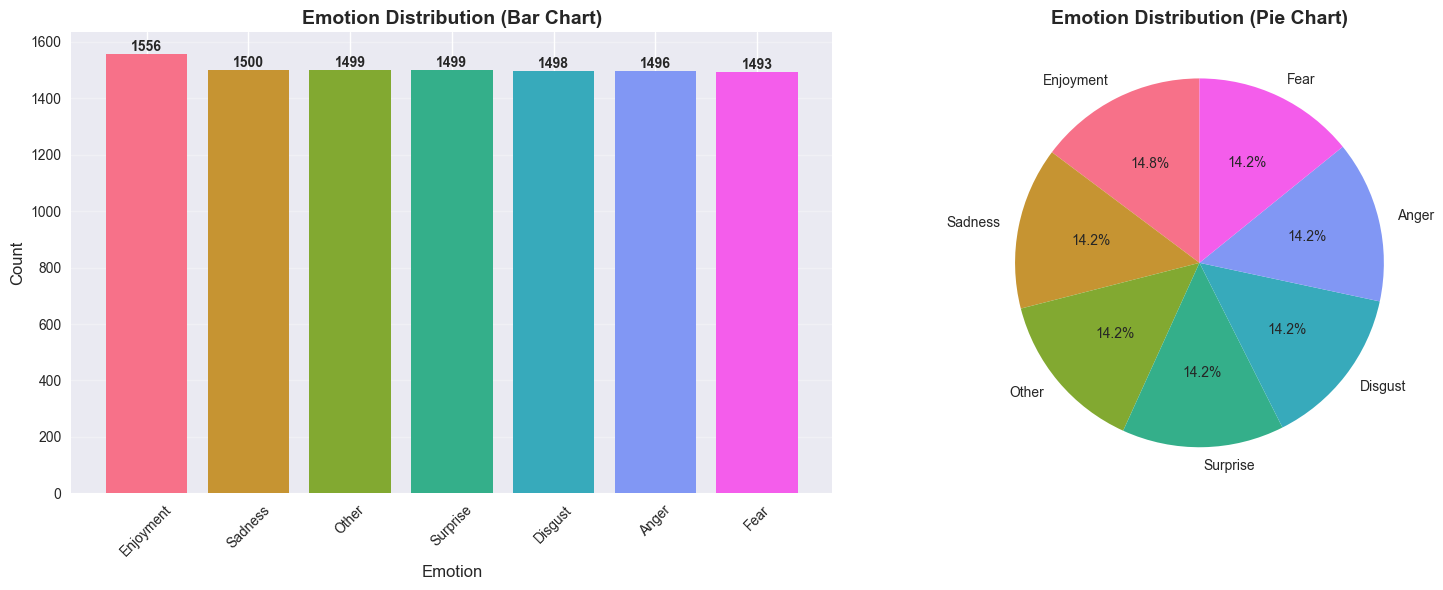


CLASS IMBALANCE ANALYSIS
Max class count: 1556
Min class count: 1493
Imbalance ratio: 1.04:1
✅ Classes are relatively balanced


In [20]:
# Visualize emotion distribution
if emotion_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    emotion_counts = df[emotion_col].value_counts()
    axes[0].bar(emotion_counts.index, emotion_counts.values, color=sns.color_palette("husl", len(emotion_counts)))
    axes[0].set_title('Emotion Distribution (Bar Chart)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Emotion', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add count labels on bars
    for i, v in enumerate(emotion_counts.values):
        axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', 
                startangle=90, colors=sns.color_palette("husl", len(emotion_counts)))
    axes[1].set_title('Emotion Distribution (Pie Chart)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Class imbalance analysis
    print(f"\n{'='*60}")
    print("CLASS IMBALANCE ANALYSIS")
    print(f"{'='*60}")
    max_count = emotion_counts.max()
    min_count = emotion_counts.min()
    imbalance_ratio = max_count / min_count
    print(f"Max class count: {max_count}")
    print(f"Min class count: {min_count}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 2:
        print("⚠️ Significant class imbalance detected!")
    else:
        print("✅ Classes are relatively balanced")


## 6. Text Statistics Analysis


In [21]:
# Identify text column (could be 'Sentence', 'text', 'sentence', etc.)
text_col = None
for col in ['Sentence', 'sentence', 'text', 'Text', 'comment', 'Comment']:
    if col in df.columns:
        text_col = col
        break

if text_col:
    print(f"✅ Found text column: '{text_col}'")
    
    # Calculate text statistics
    df['text_length'] = df[text_col].astype(str).str.len()
    df['word_count'] = df[text_col].astype(str).str.split().str.len()
    df['char_count_no_spaces'] = df[text_col].astype(str).str.replace(' ', '').str.len()
    
    print(f"\n{'='*60}")
    print("TEXT STATISTICS")
    print(f"{'='*60}")
    print(f"\n📏 Character Length Statistics:")
    print(df['text_length'].describe())
    
    print(f"\n📝 Word Count Statistics:")
    print(df['word_count'].describe())
    
    print(f"\n🔤 Character Count (no spaces) Statistics:")
    print(df['char_count_no_spaces'].describe())
    
    # Check for empty texts
    empty_texts = df[text_col].astype(str).str.strip().eq('').sum()
    print(f"\n⚠️ Empty texts: {empty_texts}")
    
else:
    print("⚠️ Could not find text column. Available columns:", df.columns.tolist())


✅ Found text column: 'Sentence'

TEXT STATISTICS

📏 Character Length Statistics:
count    10541.000000
mean        59.802960
std         39.326278
min          4.000000
25%         33.000000
50%         51.000000
75%         75.000000
max        640.000000
Name: text_length, dtype: float64

📝 Word Count Statistics:
count    10541.00000
mean        14.64842
std          9.61528
min          1.00000
25%          8.00000
50%         12.00000
75%         18.00000
max        164.00000
Name: word_count, dtype: float64

🔤 Character Count (no spaces) Statistics:
count    10541.000000
mean        46.154539
std         29.800604
min          4.000000
25%         26.000000
50%         39.000000
75%         58.000000
max        477.000000
Name: char_count_no_spaces, dtype: float64

⚠️ Empty texts: 0


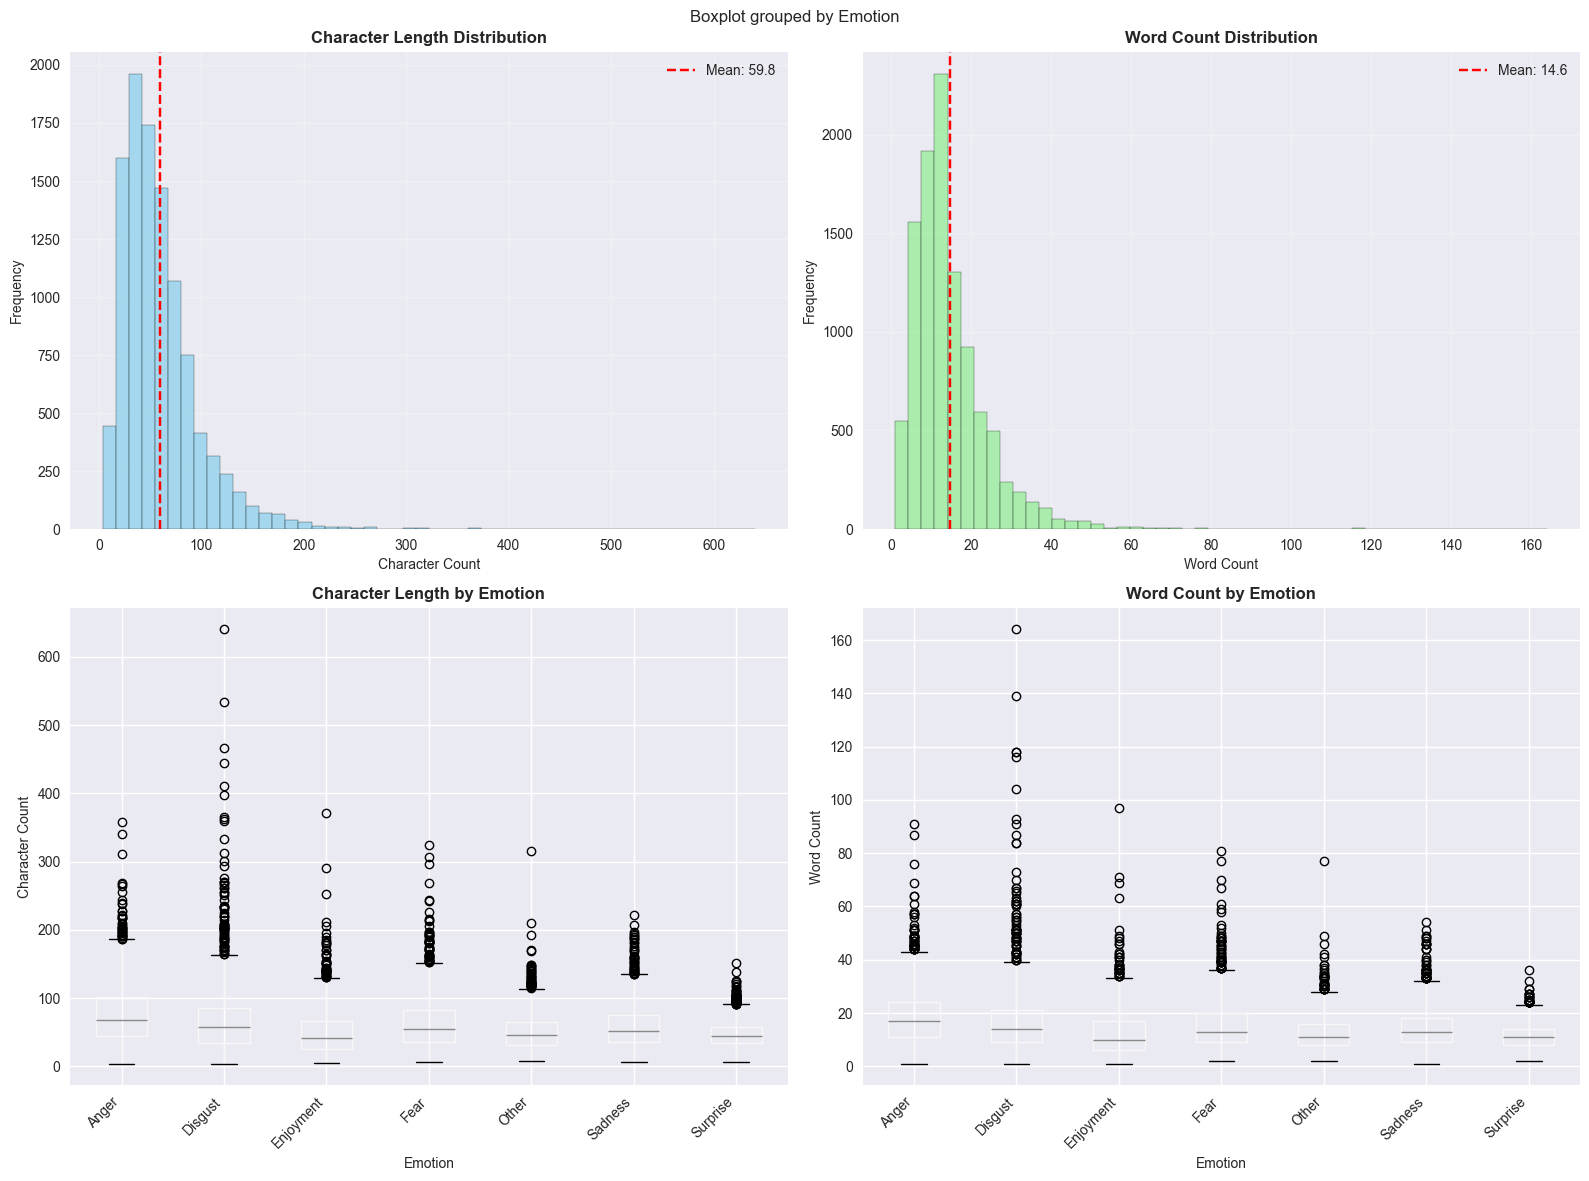

In [22]:
# Visualize text statistics
if text_col:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Character length distribution
    axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Character Length Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Character Count', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["text_length"].mean():.1f}')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Word count distribution
    axes[0, 1].hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Word Count', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["word_count"].mean():.1f}')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Box plot for character length by emotion
    if emotion_col:
        df.boxplot(column='text_length', by=emotion_col, ax=axes[1, 0])
        axes[1, 0].set_title('Character Length by Emotion', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Emotion', fontsize=10)
        axes[1, 0].set_ylabel('Character Count', fontsize=10)
        axes[1, 0].tick_params(axis='x', rotation=45)
        plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
    
    # Box plot for word count by emotion
    if emotion_col:
        df.boxplot(column='word_count', by=emotion_col, ax=axes[1, 1])
        axes[1, 1].set_title('Word Count by Emotion', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Emotion', fontsize=10)
        axes[1, 1].set_ylabel('Word Count', fontsize=10)
        axes[1, 1].tick_params(axis='x', rotation=45)
        plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()


## 7. Sample Texts by Emotion


In [23]:
# Display sample texts for each emotion
if emotion_col and text_col:
    print(f"{'='*60}")
    print("SAMPLE TEXTS BY EMOTION")
    print(f"{'='*60}")
    
    unique_emotions = df[emotion_col].unique()
    
    for emotion in sorted(unique_emotions):
        emotion_samples = df[df[emotion_col] == emotion][text_col].head(3)
        print(f"\n🎭 Emotion: {emotion} ({len(df[df[emotion_col] == emotion])} samples)")
        print("-" * 60)
        for idx, (i, text) in enumerate(emotion_samples.items(), 1):
            text_preview = str(text)[:150] + "..." if len(str(text)) > 150 else str(text)
            print(f"  Sample {idx}: {text_preview}")
        print()


SAMPLE TEXTS BY EMOTION

🎭 Emotion: Anger (1496 samples)
------------------------------------------------------------
  Sample 1: Thằng chó đẻ, mày làm vỡ màn hình bố rồi!
  Sample 2: Biến ra chỗ khác mà viết đi hộ cái 😈.
  Sample 3: Mày để cái tiếng bình thường thôi cho dễ nghe, làm cái đéo gì vậy.


🎭 Emotion: Disgust (1498 samples)
------------------------------------------------------------
  Sample 1: Quá cẩu thả, vậy mà giam người ta gần 7 năm, giờ đền bù có 200 củ. Chị ấy quá oan ức, còn mấy tên kia thì tệ bạc không thể tả.
  Sample 2: per cái đó là ngu chứ thik đéo gì
  Sample 3: Chính sách quản lý yếu kém nên mới ra nông nỗi này.


🎭 Emotion: Enjoyment (1556 samples)
------------------------------------------------------------
  Sample 1: khi nhỏ còn bị nghiện mùi khói này nữa chớ . 😄
  Sample 2: bố là số 1 vĩ đại hơn những gì con cần
  Sample 3: thề cưng thiệc sự =))


🎭 Emotion: Fear (1493 samples)
------------------------------------------------------------
  Sample 1: Đi n

## 8. Statistical Summary by Emotion


In [24]:
# Statistical summary grouped by emotion
if emotion_col and text_col:
    print(f"{'='*60}")
    print("STATISTICAL SUMMARY BY EMOTION")
    print(f"{'='*60}")
    
    summary_stats = df.groupby(emotion_col).agg({
        'text_length': ['count', 'mean', 'std', 'min', 'max'],
        'word_count': ['mean', 'std', 'min', 'max']
    }).round(2)
    
    print(summary_stats)
    
    # Create a more readable summary
    print(f"\n{'='*60}")
    print("AVERAGE TEXT LENGTH BY EMOTION")
    print(f"{'='*60}")
    avg_stats = df.groupby(emotion_col).agg({
        'text_length': 'mean',
        'word_count': 'mean'
    }).round(2)
    avg_stats.columns = ['Avg Characters', 'Avg Words']
    avg_stats = avg_stats.sort_values('Avg Characters', ascending=False)
    print(avg_stats)


STATISTICAL SUMMARY BY EMOTION
          text_length                        word_count                
                count   mean    std min  max       mean    std min  max
Emotion                                                                
Anger            1496  77.58  46.39   4  358      18.88  11.15   1   91
Disgust          1498  68.77  54.87   4  640      16.97  13.72   1  164
Enjoyment        1556  50.68  34.55   5  371      12.56   8.61   1   97
Fear             1493  63.98  39.59   6  324      15.62   9.61   2   81
Other            1499  51.56  27.25   8  316      12.69   6.59   2   77
Sadness          1500  59.08  32.42   6  222      14.44   7.85   1   54
Surprise         1499  47.38  20.19   7  151      11.47   4.67   2   36

AVERAGE TEXT LENGTH BY EMOTION
           Avg Characters  Avg Words
Emotion                             
Anger               77.58      18.88
Disgust             68.77      16.97
Fear                63.98      15.62
Sadness             59.08      1

## 9. Duplicate Analysis


In [25]:
# Check for duplicate texts
if text_col:
    print(f"{'='*60}")
    print("DUPLICATE ANALYSIS")
    print(f"{'='*60}")
    
    duplicate_texts = df[text_col].duplicated().sum()
    print(f"📊 Total duplicate texts: {duplicate_texts}")
    print(f"📊 Percentage of duplicates: {(duplicate_texts/len(df)*100):.2f}%")
    
    if duplicate_texts > 0:
        print(f"\n⚠️ Found {duplicate_texts} duplicate texts")
        print("\nSample duplicate texts:")
        duplicates = df[df[text_col].duplicated(keep=False)].sort_values(text_col)
        print(duplicates[[text_col, emotion_col] if emotion_col else [text_col]].head(10))
    else:
        print("✅ No duplicate texts found!")
    
    # Check for duplicate rows (all columns)
    duplicate_rows = df.duplicated().sum()
    print(f"\n📊 Total duplicate rows: {duplicate_rows}")
    if duplicate_rows > 0:
        print(f"⚠️ Found {duplicate_rows} completely duplicate rows")


DUPLICATE ANALYSIS
📊 Total duplicate texts: 0
📊 Percentage of duplicates: 0.00%
✅ No duplicate texts found!

📊 Total duplicate rows: 0


## 10. Summary and Conclusions


In [26]:
# Final summary
print(f"{'='*60}")
print("EDA SUMMARY")
print(f"{'='*60}")

print(f"\n📊 Dataset Overview:")
print(f"  • Total samples: {len(df)}")
print(f"  • Total columns: {len(df.columns)}")
print(f"  • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if emotion_col:
    print(f"\n🎭 Emotion Analysis:")
    print(f"  • Unique emotions: {df[emotion_col].nunique()}")
    print(f"  • Emotion distribution:")
    for emotion, count in df[emotion_col].value_counts().items():
        print(f"    - {emotion}: {count} ({count/len(df)*100:.1f}%)")

if text_col:
    print(f"\n📝 Text Analysis:")
    print(f"  • Average text length: {df['text_length'].mean():.1f} characters")
    print(f"  • Average word count: {df['word_count'].mean():.1f} words")
    print(f"  • Min text length: {df['text_length'].min()} characters")
    print(f"  • Max text length: {df['text_length'].max()} characters")

print(f"\n✅ EDA Complete!")


EDA SUMMARY

📊 Dataset Overview:
  • Total samples: 10541
  • Total columns: 7
  • Memory usage: 7.85 MB

🎭 Emotion Analysis:
  • Unique emotions: 7
  • Emotion distribution:
    - Enjoyment: 1556 (14.8%)
    - Sadness: 1500 (14.2%)
    - Other: 1499 (14.2%)
    - Surprise: 1499 (14.2%)
    - Disgust: 1498 (14.2%)
    - Anger: 1496 (14.2%)
    - Fear: 1493 (14.2%)

📝 Text Analysis:
  • Average text length: 59.8 characters
  • Average word count: 14.6 words
  • Min text length: 4 characters
  • Max text length: 640 characters

✅ EDA Complete!
